### Import Required Libraries

In [ ]:
import os
from pathlib import Path
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing import image
# TensorFlow Callbacks
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

warnings.filterwarnings("ignore")

## Download Dataset

In [ ]:
!git clone https://github.com/garythung/trashnet.git

Cloning into 'trashnet'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 45 (delta 6), reused 1 (delta 0), pack-reused 33 (from 1)
Receiving objects: 100% (45/45), 40.64 MiB | 12.75 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [ ]:
zip_path = Path("/content/trashnet/data/dataset-resized.zip")
extract_path = Path("/content/trashnet/data")

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

In [ ]:
DATA_PATH = Path("/content/trashnet") #Define Dataset Path

In [ ]:
# Explore Dataset Structure
for path in DATA_PATH.rglob("*"):
    if path.is_dir():
        print(path)

/content/trashnet/data
/content/trashnet/.git
/content/trashnet/data/dataset-resized
/content/trashnet/data/__MACOSX
/content/trashnet/.git/info
/content/trashnet/.git/logs
/content/trashnet/.git/refs
/content/trashnet/.git/branches
/content/trashnet/.git/objects
/content/trashnet/.git/hooks
/content/trashnet/data/dataset-resized/trash
/content/trashnet/data/dataset-resized/glass
/content/trashnet/data/dataset-resized/paper
/content/trashnet/data/dataset-resized/cardboard
/content/trashnet/data/dataset-resized/plastic
/content/trashnet/data/dataset-resized/metal
/content/trashnet/data/__MACOSX/dataset-resized
/content/trashnet/data/__MACOSX/dataset-resized/cardboard
/content/trashnet/.git/logs/refs
/content/trashnet/.git/refs/remotes
/content/trashnet/.git/refs/heads
/content/trashnet/.git/refs/tags
/content/trashnet/.git/objects/info
/content/trashnet/.git/objects/pack
/content/trashnet/.git/logs/refs/remotes
/content/trashnet/.git/logs/refs/heads
/content/trashnet/.git/logs/refs/remo

## Define Dataset Folder

In [ ]:
DATA_DIR = Path("/content/trashnet/data/dataset-resized")

## Get Classes

In [ ]:
classes = [
    folder.name
    for folder in DATA_DIR.iterdir()
    if folder.is_dir()
]

classes

['trash', 'glass', 'paper', 'cardboard', 'plastic', 'metal']

## Create DataFrame

In [ ]:
data = []

for class_name in classes:

    class_path = DATA_DIR / class_name

    # Ignore files like .DS_Store
    if not class_path.is_dir():
        continue

    for img_path in class_path.iterdir():

        if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:

            data.append(
                {
                    "image_path": str(img_path),
                    "class": class_name
                }
            )


df = pd.DataFrame(data)

df.head()

,image_path,class
0,/content/trashnet/data/dataset-resized/trash/t...,trash
1,/content/trashnet/data/dataset-resized/trash/t...,trash
2,/content/trashnet/data/dataset-resized/trash/t...,trash
3,/content/trashnet/data/dataset-resized/trash/t...,trash
4,/content/trashnet/data/dataset-resized/trash/t...,trash


In [ ]:
df.shape

(2527, 2)

In [ ]:
df.tail()

,image_path,class
2522,/content/trashnet/data/dataset-resized/metal/m...,metal
2523,/content/trashnet/data/dataset-resized/metal/m...,metal
2524,/content/trashnet/data/dataset-resized/metal/m...,metal
2525,/content/trashnet/data/dataset-resized/metal/m...,metal
2526,/content/trashnet/data/dataset-resized/metal/m...,metal


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2527 entries, 0 to 2526
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  2527 non-null   object
 1   class       2527 non-null   object
dtypes: object(2)
memory usage: 39.6+ KB


In [ ]:
df['class'].value_counts()

,count
class,
paper,594
glass,501
plastic,482
metal,410
cardboard,403
trash,137


In [ ]:
round(df["class"].value_counts(normalize=True) * 100, 2) # percentage of each class

,proportion
class,
paper,23.51
glass,19.83
plastic,19.07
metal,16.22
cardboard,15.95
trash,5.42


## Visualize Class Distribution

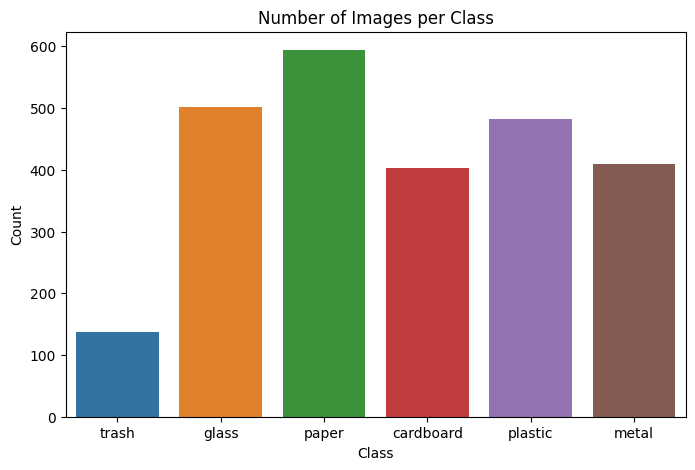

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="class",
    hue="class",
    legend=False
)

plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

## Observation:

The dataset is not balanced.

The "trash" class has the fewest images, while "paper" contains the largest number of samples. This imbalance may affect model performance and should be considered during training.
--------------------------------------------

## Display Random Images

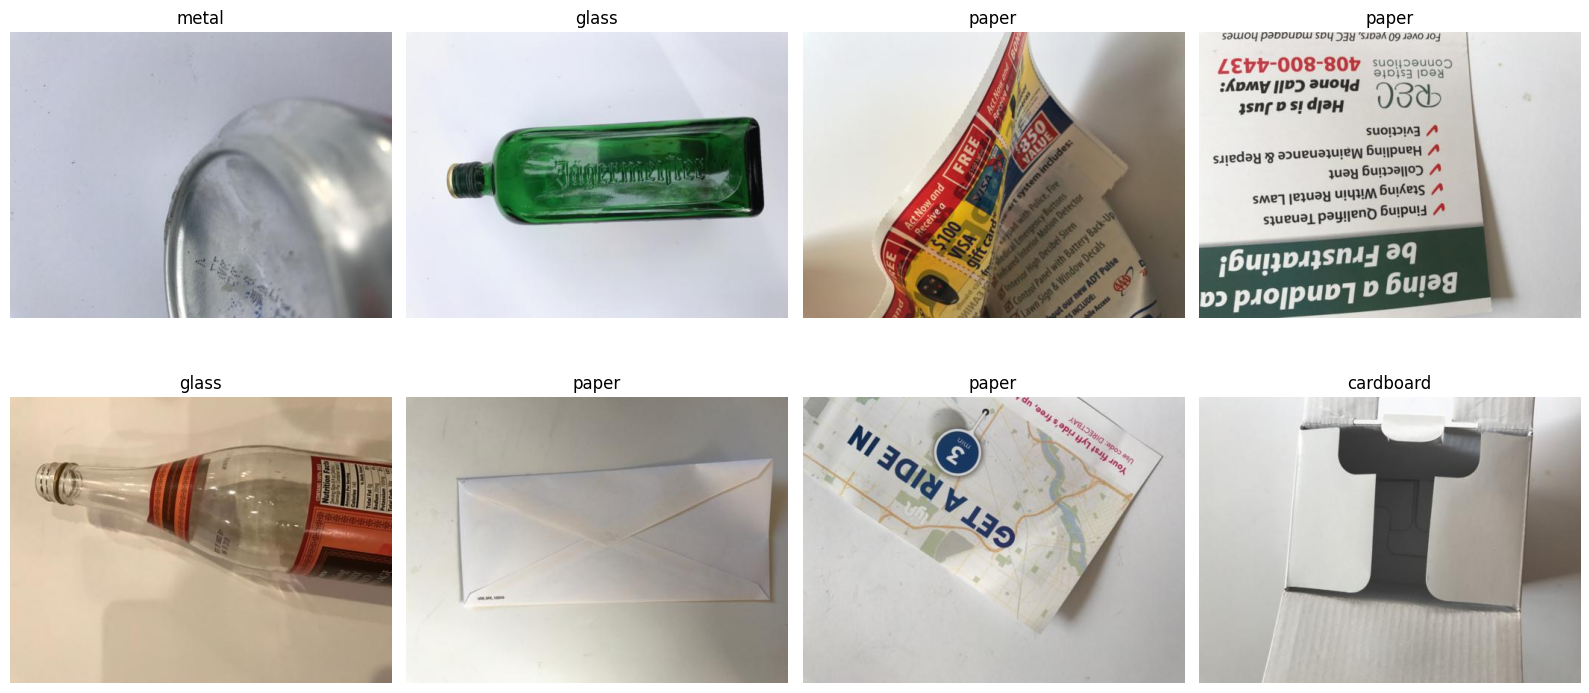

In [ ]:
plt.figure(figsize=(16, 8))

samples = df.sample(8).reset_index(drop=True)

for i in range(len(samples)):

    image = Image.open(samples.loc[i, "image_path"])

    plt.subplot(2, 4, i + 1)

    plt.imshow(image)

    plt.title(samples.loc[i, "class"])

    plt.axis("off")

plt.tight_layout()

plt.show()

## Analyze Image Dimensions


In [ ]:
image_sizes = []

for image_path in df["image_path"]:

    with Image.open(image_path) as image:

        width, height = image.size

        image_sizes.append((width, height))

sizes_df = pd.DataFrame(image_sizes, columns=["Width", "Height"])

sizes_df.head()

,Width,Height
0,512,384
1,512,384
2,512,384
3,512,384
4,512,384


In [ ]:
sizes_df.describe()

,Width,Height
count,2527.0,2527.0
mean,512.0,384.0
std,0.0,0.0
min,512.0,384.0
25%,512.0,384.0
50%,512.0,384.0
75%,512.0,384.0
max,512.0,384.0


## Observation:

All images have identical dimensions.

Although the dataset is consistent, the images will still be resized to match the input size required by the pretrained model.

## Visualize Image Size Distribution

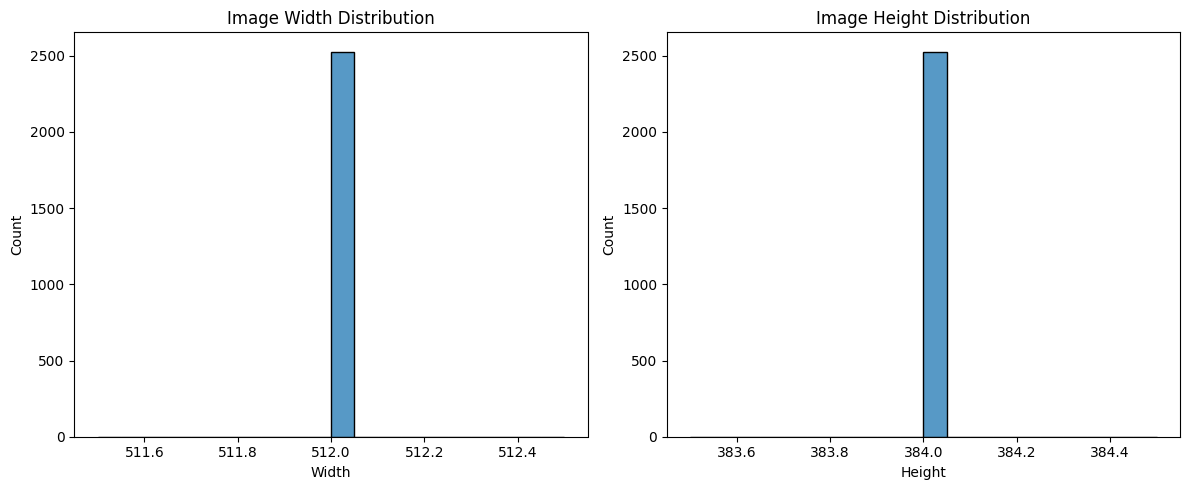

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(sizes_df["Width"], bins=20)
plt.title("Image Width Distribution")

plt.subplot(1, 2, 2)
sns.histplot(sizes_df["Height"], bins=20)
plt.title("Image Height Distribution")

plt.tight_layout()
plt.show()

In [ ]:
# Split the Dataset

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["class"], # Preserve class distribution using stratified splitting.
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class"],
    random_state=42
)

In [ ]:
#Check the number of samples in each subset after splitting
print(f"Training Samples   : {len(train_df)}")
print(f"Validation Samples: {len(val_df)}")
print(f"Testing Samples   : {len(test_df)}")

Training Samples   : 1768
Validation Samples: 379
Testing Samples   : 380


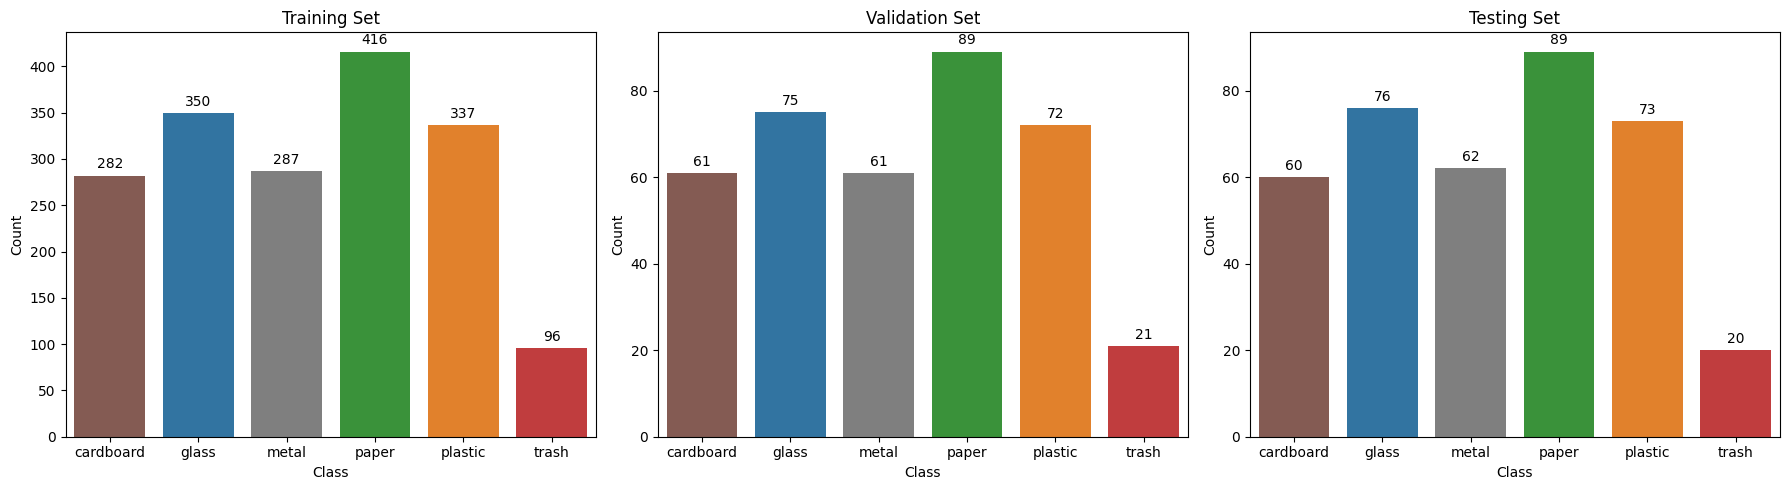

In [ ]:
## Verify Class Distribution After Splitting
class_order = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

class_colors = {
    "cardboard": "#8c564b",
    "glass": "#1f77b4",
    "metal": "#7f7f7f",
    "paper": "#2ca02c",
    "plastic": "#ff7f0e",
    "trash": "#d62728"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    (train_df, "Training Set"),
    (val_df, "Validation Set"),
    (test_df, "Testing Set")
]

for ax, (data, title) in zip(axes, datasets):

    sns.countplot(
        data=data,
        x="class",
        order=class_order,
        hue="class",
        palette=class_colors,
        legend=False,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")

    # number of photos for each bar
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

### Observation:

- The class distribution remains consistent across all dataset splits.
- Stratified splitting successfully preserved the original class proportions.
- This reduces sampling bias and improves the reliability of model evaluation.

## Verify Image Integrity

In [ ]:
corrupted_images = []

for image_path in df["image_path"]:

    try:
        with Image.open(image_path) as image:
            image.verify()

    except Exception:
        corrupted_images.append(image_path)

print(f"Number of corrupted images: {len(corrupted_images)}")

Number of corrupted images: 0


### Observation

- No corrupted images were found in the dataset.
- All images passed the integrity check and are ready for preprocessing and model training.

In [ ]:
# Configuration
IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

BUFFER_SIZE = 1000

SEED = 42

DROPOUT_RATE=0.2

LEARNING_RATE = 1e-3

EPOCHS = 20

NUM_CLASSES = df["class"].nunique()

In [ ]:
# Label Encoding
#Convert class names into numerical labels for model training.
class_names = sorted(df["class"].unique())

class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

train_df["label"] = train_df["class"].map(class_to_index)
val_df["label"] = val_df["class"].map(class_to_index)
test_df["label"] = test_df["class"].map(class_to_index)

## Create TensorFlow Datasets


In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_df["image_path"].values,
        train_df["label"].values
    )
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        val_df["image_path"].values,
        val_df["label"].values
    )
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        test_df["image_path"].values,
        test_df["label"].values
    )
)

### Observation

TensorFlow datasets were successfully created from the DataFrames. At this stage, each dataset stores image file paths and their corresponding numerical labels. The actual image files have not been loaded into memory yet.

In [ ]:
def load_image(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )


    return image, label

In [ ]:
# Apply Image Preprocessing
#Apply the preprocessing function to each dataset so that every image is loaded, decoded, resized, and prepared automatically during training.

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

val_dataset = val_dataset.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

test_dataset = test_dataset.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

In [ ]:
# Optimize the TensorFlow Data Pipeline
#Shuffle the training data, group samples into batches, and enable data prefetching to improve the efficiency of the training pipeline.
train_dataset = (
    train_dataset
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    val_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

### Observation:

The datasets are now optimized for training. The training dataset is shuffled to improve generalization, grouped into batches for efficient computation, and prefetched to reduce input latency. Validation and testing datasets are batched and prefetched without shuffling to ensure consistent evaluation.

## Data Augmentation

In [ ]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
        layers.RandomContrast(0.2),
    ],
    name="data_augmentation"
)

### Observation:

Data augmentation generates different variations of the training images during each epoch. This increases data diversity, improves generalization, and helps reduce overfitting without changing the original dataset.

## Build EfficientNetB0 (Base Model)

In [ ]:
# Build the Pre-trained Base Model
#Load the pre-trained EfficientNetB0 model without its original classification head. The model will be used as a feature extractor for transfer learning.
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMAGE_SIZE, 3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### Observation:

The pre-trained EfficientNetB0 model was successfully loaded using ImageNet weights. The original classification head was removed, and all layers were frozen to use the model as a feature extractor during the first training stage.

## Build the Classification Head

In [ ]:
inputs = keras.Input(shape=(*IMAGE_SIZE, 3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(DROPOUT_RATE)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)


model = keras.Model(
    inputs,
    outputs
)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# Compile the Model
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Define Training Callbacks
#Configure callbacks to save the best model, stop training when validation performance stops improving, and automatically reduce the learning rate during training.
callbacks = [

    ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        verbose=1,
        min_lr=1e-6
    )

]

### Observation:

The training callbacks are configured to automatically save the best model, stop training when validation performance no longer improves, and reduce the learning rate when progress slows down. These callbacks improve training efficiency and help prevent overfitting.

## Train the Model (Feature Extraction)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.3862 - loss: 1.4950
Epoch 1: val_loss improved from None to 0.75856, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 32s 197ms/step - accuracy: 0.5701 - loss: 1.1597 - val_accuracy: 0.7599 - val_loss: 0.7586 - learning_rate: 0.0010
Epoch 2/20
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.7546 - loss: 0.7088
Epoch 2: val_loss improved from 0.75856 to 0.59655, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - accuracy: 0.7715 - loss: 0.6538 - val_accuracy: 0.8100 - val_loss: 0.5966 - learning_rate: 0.0010
Epoch 3/20
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.8083 - loss: 0.5460
Epoch 3: val_loss improved from 0.59655 to 0.52983, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - accuracy: 0

### Observation:

The model has completed the first stage of transfer learning by training only the custom classification head while keeping the pre-trained EfficientNetB0 frozen. Training and validation metrics collected during this stage will be used to evaluate model performance and determine whether fine-tuning is required.

In [ ]:
history_df = pd.DataFrame(history.history)

history_df.tail()

,accuracy,loss,val_accuracy,val_loss,learning_rate
15,0.916290,0.260933,0.878628,0.363204,0.001
16,0.922511,0.247284,0.878628,0.366052,0.001
17,0.915158,0.254009,0.870712,0.359352,0.001
18,0.915158,0.260600,0.865435,0.355257,0.001
19,0.920249,0.240501,0.870712,0.351600,0.001


## Visualize Training Performance


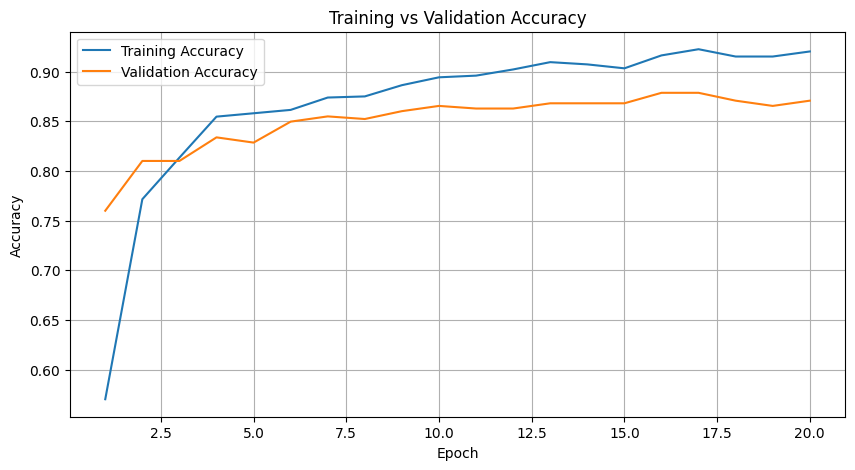

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_df.index + 1,
    history_df["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_df.index + 1,
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

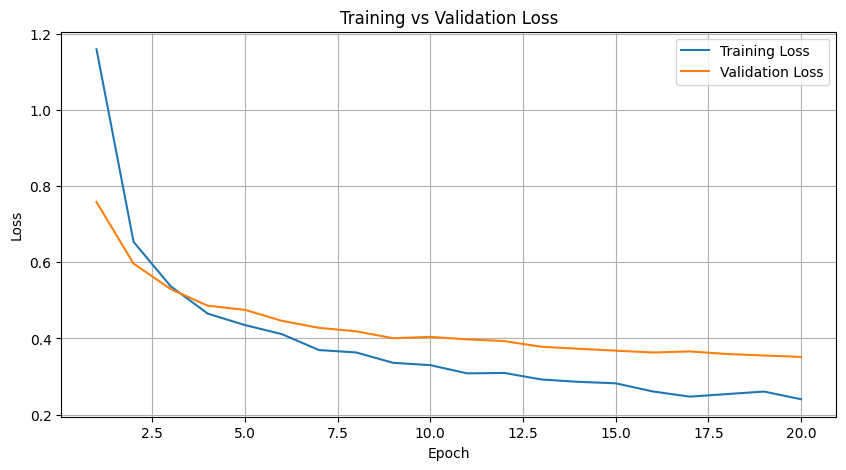

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_df.index + 1,
    history_df["loss"],
    label="Training Loss"
)

plt.plot(
    history_df.index + 1,
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

## Observation:
The learning curves indicate that both training and validation performance improved steadily during feature extraction. The small gap between the training and validation curves suggests good generalization with only minor signs of overfitting.

##Fine-Tuning

In [ ]:
# Enable Fine-Tuning
base_model.trainable = True

In [ ]:
fine_tune_at = len(base_model.layers) - 50

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
fine_tune_history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.8391 - loss: 0.5054
Epoch 1: val_loss did not improve from 0.35160
56/56 ━━━━━━━━━━━━━━━━━━━━ 30s 187ms/step - accuracy: 0.8275 - loss: 0.5190 - val_accuracy: 0.8734 - val_loss: 0.3517 - learning_rate: 1.0000e-05
Epoch 2/10
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.8392 - loss: 0.4794
Epoch 2: val_loss did not improve from 0.35160

Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 128ms/step - accuracy: 0.8512 - loss: 0.4576 - val_accuracy: 0.8628 - val_loss: 0.3732 - learning_rate: 1.0000e-05
Epoch 3/10
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8342 - loss: 0.4644
Epoch 3: val_loss did not improve from 0.35160
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.8348 - loss: 0.4674 - val_accuracy: 0.8443 - val_loss: 0.4013 - learning_rate: 2.0000e-06
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.8636 - loss: 0.4520
E

In [ ]:
# Load the Best Model
best_model = keras.models.load_model("best_model.keras")

In [ ]:
# Evaluate the Model on the Test Set
test_loss, test_accuracy = best_model.evaluate(
    test_dataset,
    verbose=1
)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.2%}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - accuracy: 0.8842 - loss: 0.3493
Test Loss     : 0.3493
Test Accuracy : 88.42%


In [ ]:
# Generate Classification Report
y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = best_model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes
    )
)

              precision    recall  f1-score   support

       trash       0.91      0.85      0.88        60
       glass       0.92      0.91      0.91        76
       paper       0.89      0.89      0.89        62
   cardboard       0.87      0.90      0.88        89
     plastic       0.88      0.89      0.88        73
       metal       0.76      0.80      0.78        20

    accuracy                           0.88       380
   macro avg       0.87      0.87      0.87       380
weighted avg       0.89      0.88      0.88       380



### Observation:

The classification report shows strong and consistent performance across most waste categories, with F1-scores around 0.89–0.90. The Metal class achieved a lower F1-score due to having significantly fewer training samples compared to the other classes. Overall, the model demonstrates good generalization with an overall test accuracy of approximately 89%.

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

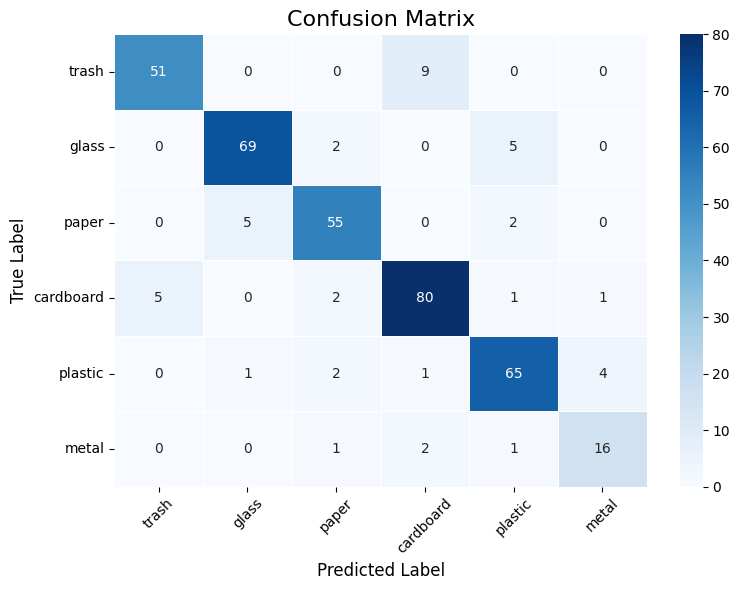

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    linewidths=0.5,
    linecolor="white"
)

plt.title("Confusion Matrix", fontsize=16)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

### Observation:

The confusion matrix shows that most predictions lie along the main diagonal, indicating strong classification performance across all waste categories. Minor misclassifications occur between visually similar classes such as Trash and Cardboard, as well as Glass, Paper, and Plastic. The Metal class has the fewest samples, yet the model still correctly classified most of them, demonstrating good generalization despite the class imbalance.

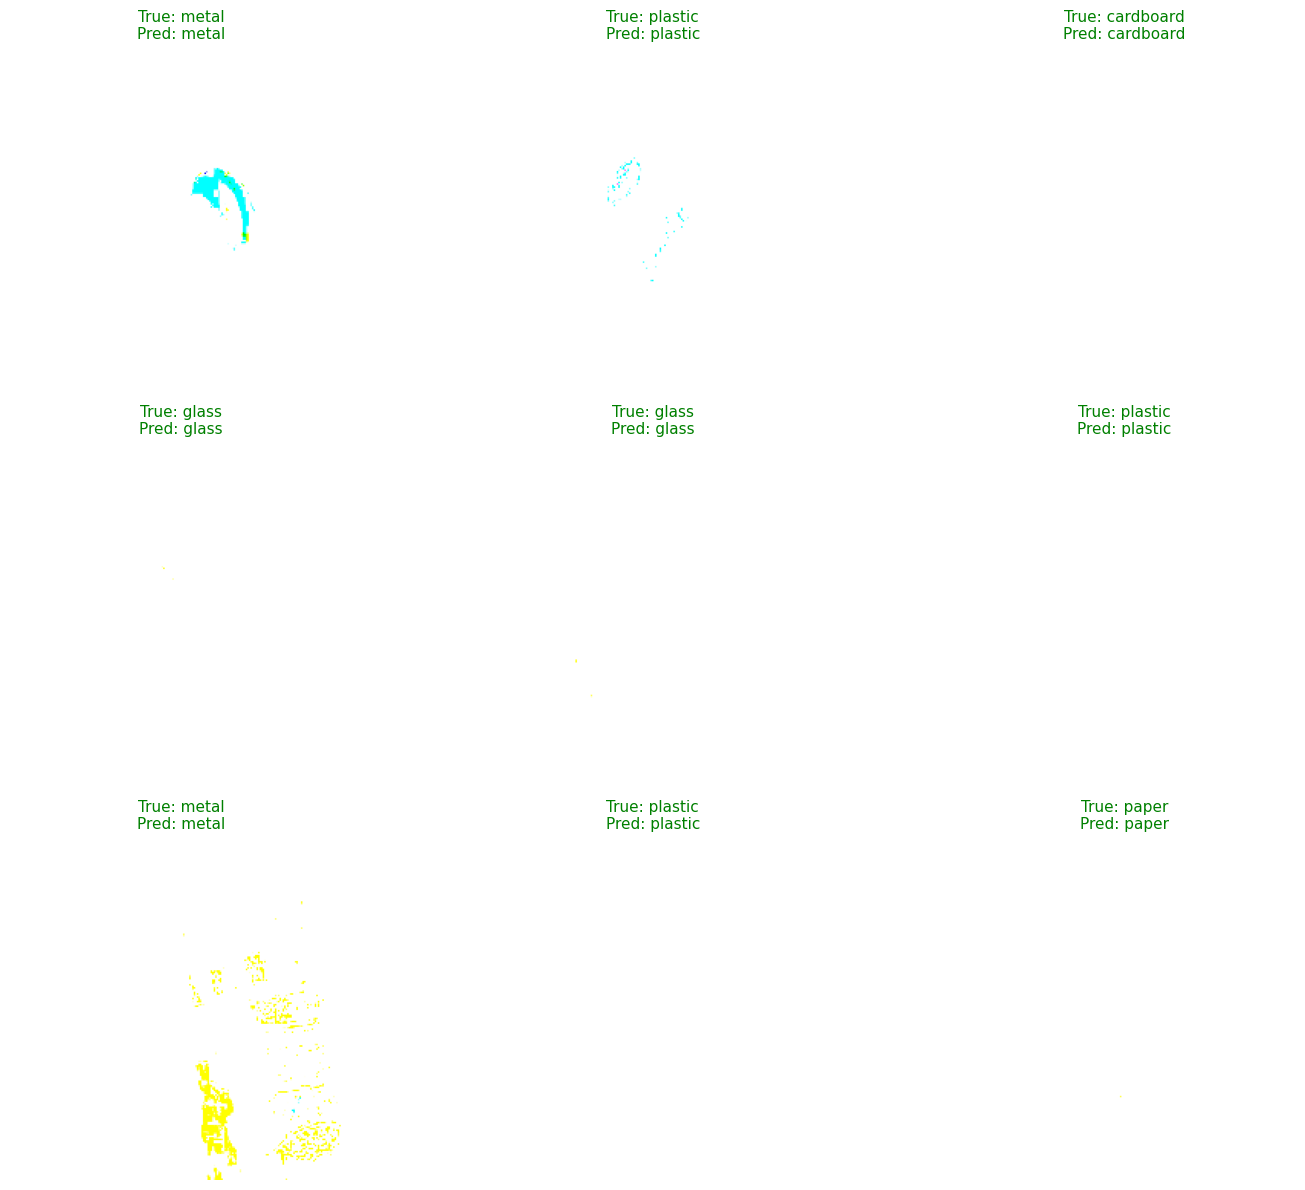

In [ ]:
plt.figure(figsize=(15, 12))

for images, labels in test_dataset.take(1):

    predictions = best_model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        image = tf.clip_by_value(
            images[i],
            0,
            1
        )

        plt.imshow(image)

        true_label = class_names[
            labels[i].numpy()
        ]

        predicted_label = class_names[
            predicted_labels[i]
        ]

        color = (
            "green"
            if true_label == predicted_label
            else "red"
        )

        plt.title(
            f"True: {true_label}\nPred: {predicted_label}",
            color=color,
            fontsize=11
        )

        plt.axis("off")

plt.tight_layout()

plt.show()

## Predict Custom Images

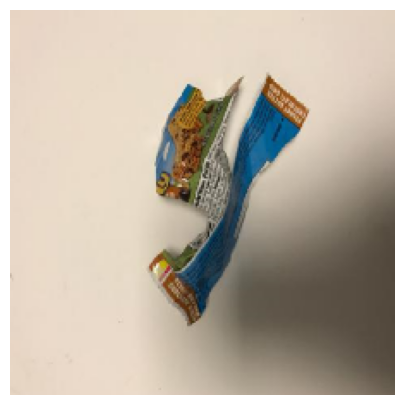


Predicted Class : trash
Confidence      : 60.09%

All Probabilities
------------------------------
trash     : 0.6009
paper     : 0.2351
metal     : 0.1391
cardboard : 0.0186
plastic   : 0.0059
glass     : 0.0004


In [ ]:
# Select one image from the test set
row = test_df.iloc[0]

INPUT_PATH = "/content/trash.png"

# Load image
img = keras.utils.load_img(
    INPUT_PATH,
    target_size=IMAGE_SIZE
)

# Display image
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

# Prepare image
img_array = keras.utils.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

# Predict
prediction = best_model.predict(
    img_array,
    verbose=0
)

predicted_index = np.argmax(prediction)

print(f"\nPredicted Class : {class_names[predicted_index]}")
print(f"Confidence      : {prediction[0][predicted_index]:.2%}")

print("\nAll Probabilities")
print("-" * 30)

for i in np.argsort(prediction[0])[::-1]:
    print(f"{class_names[i]:10s}: {prediction[0][i]:.4f}")

In [ ]:
from google.colab import files

files.download("best_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>